In [7]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.datasets import make_blobs

In [8]:
X,y=make_blobs(n_samples=1000,n_features=2,centers=3)

In [9]:
X

array([[-4.82788182,  3.28805771],
       [-4.92565776, -5.46603306],
       [ 9.57857204,  1.79199765],
       ...,
       [ 9.23788254,  0.34178679],
       [-3.56777686, -6.07009368],
       [-5.36578845,  3.41927493]])

In [10]:
y

array([2, 1, 0, 2, 0, 2, 0, 2, 0, 2, 1, 1, 2, 0, 2, 0, 2, 1, 1, 0, 0, 1,
       2, 2, 0, 2, 0, 1, 2, 1, 0, 0, 1, 2, 1, 0, 0, 0, 1, 2, 2, 2, 1, 2,
       0, 2, 1, 0, 2, 2, 2, 1, 2, 2, 1, 1, 1, 0, 0, 0, 1, 2, 1, 1, 2, 1,
       2, 0, 2, 2, 1, 2, 0, 1, 2, 1, 0, 0, 2, 0, 0, 1, 1, 1, 2, 0, 1, 0,
       2, 2, 0, 1, 1, 2, 2, 0, 2, 1, 0, 0, 1, 0, 2, 1, 2, 2, 0, 1, 0, 2,
       0, 2, 1, 0, 0, 2, 2, 2, 1, 2, 1, 0, 1, 0, 1, 1, 0, 0, 1, 2, 2, 1,
       2, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 1, 2, 2, 0, 0, 2, 0, 1, 2, 1, 2,
       0, 1, 0, 1, 1, 2, 1, 1, 2, 2, 1, 0, 1, 0, 1, 2, 0, 0, 0, 1, 2, 0,
       1, 2, 2, 1, 2, 1, 0, 1, 0, 0, 2, 1, 1, 1, 1, 1, 1, 2, 1, 0, 1, 0,
       2, 0, 0, 2, 0, 2, 2, 1, 2, 2, 2, 1, 0, 1, 0, 0, 0, 2, 1, 2, 1, 2,
       2, 0, 2, 1, 2, 2, 0, 1, 2, 1, 0, 1, 0, 1, 2, 1, 1, 1, 0, 0, 0, 2,
       1, 1, 2, 2, 2, 0, 0, 0, 0, 1, 0, 1, 2, 2, 2, 1, 2, 0, 2, 1, 1, 2,
       0, 0, 2, 1, 1, 0, 0, 2, 0, 1, 1, 2, 2, 0, 0, 2, 0, 1, 0, 1, 0, 1,
       2, 0, 0, 2, 1, 0, 2, 1, 0, 0, 1, 2, 2, 1, 1,

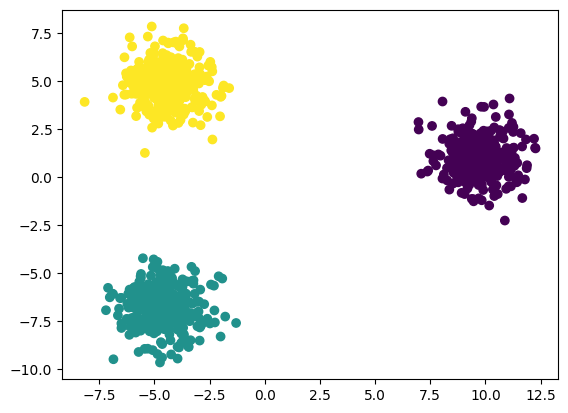

In [11]:
plt.scatter(X[:,0],X[:,1],c=y)

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

std=StandardScaler()

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=24)

In [14]:
X_train_scaled=std.fit_transform(X_train)
X_test_scaled=std.transform(X_test)

In [15]:
from sklearn.cluster import KMeans

In [16]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [17]:
wcss

[1499.9999999999984,
 645.8785799588059,
 47.50551685594686,
 41.06693862270197,
 38.42926535193824,
 27.259730805110166,
 25.31606811665843,
 22.75961421078789,
 20.743903091537245,
 19.507337372785614]

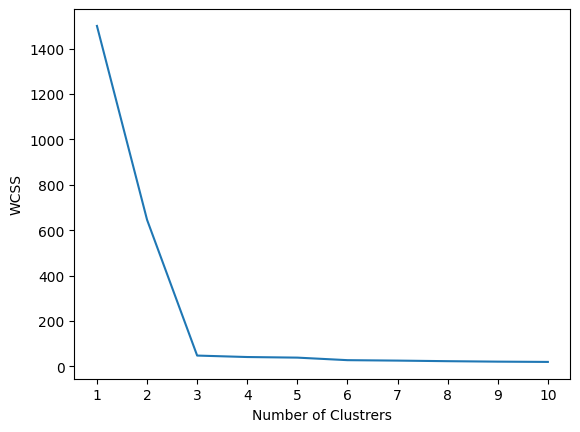

In [18]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [19]:
kmeans=KMeans(n_clusters=3,init='k-means++')
kmeans.fit_predict(X_train_scaled)

array([2, 0, 2, 0, 1, 2, 1, 1, 2, 2, 0, 1, 1, 2, 2, 0, 0, 2, 0, 1, 1, 2,
       1, 1, 2, 1, 1, 1, 1, 2, 0, 2, 0, 2, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 2, 1, 2, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 2, 1, 0, 0, 2, 1, 0, 2,
       1, 1, 1, 0, 2, 0, 1, 2, 0, 1, 0, 2, 2, 1, 1, 2, 1, 1, 1, 2, 2, 2,
       0, 0, 0, 2, 1, 0, 2, 1, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 1,
       0, 2, 0, 1, 2, 1, 2, 2, 1, 1, 0, 2, 2, 0, 0, 1, 1, 2, 0, 1, 2, 1,
       2, 2, 0, 2, 1, 0, 0, 0, 1, 1, 2, 1, 2, 1, 1, 0, 0, 2, 1, 1, 0, 1,
       0, 2, 2, 0, 2, 2, 2, 1, 2, 1, 0, 2, 0, 2, 0, 2, 1, 0, 1, 1, 1, 2,
       1, 1, 1, 1, 1, 2, 1, 2, 0, 0, 0, 0, 1, 2, 2, 2, 0, 2, 0, 1, 0, 1,
       0, 1, 1, 2, 0, 1, 1, 2, 1, 1, 1, 0, 1, 1, 2, 0, 1, 2, 2, 0, 1, 1,
       2, 0, 1, 0, 0, 1, 2, 2, 2, 0, 0, 0, 1, 2, 0, 2, 0, 2, 1, 0, 0, 1,
       2, 2, 2, 0, 2, 0, 1, 0, 0, 1, 0, 1, 2, 1, 2, 2, 1, 0, 0, 1, 2, 0,
       2, 2, 0, 1, 0, 2, 2, 1, 1, 2, 2, 0, 1, 2, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 2, 1, 0, 1, 2, 1, 1, 1, 0, 1, 0, 1, 1, 2,

In [20]:
y_pred=kmeans.predict(X_test_scaled)

In [22]:
y_pred

array([0, 0, 2, 0, 0, 1, 2, 0, 2, 2, 0, 2, 2, 0, 2, 1, 1, 0, 1, 2, 1, 0,
       2, 1, 2, 0, 0, 2, 2, 1, 1, 0, 2, 0, 2, 2, 1, 1, 2, 1, 0, 2, 1, 2,
       1, 2, 2, 0, 0, 0, 2, 0, 2, 1, 1, 0, 2, 0, 2, 0, 2, 2, 0, 1, 0, 2,
       1, 2, 1, 2, 0, 1, 1, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 1, 0, 0, 1, 2,
       2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 0, 0, 2, 0, 1, 1,
       2, 2, 0, 2, 2, 0, 0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 0, 2, 0, 0, 0, 2,
       1, 2, 0, 2, 0, 2, 2, 0, 0, 0, 2, 2, 2, 2, 2, 0, 2, 0, 1, 0, 0, 1,
       1, 0, 2, 2, 2, 0, 2, 0, 1, 2, 1, 0, 1, 1, 0, 1, 0, 0, 2, 1, 1, 1,
       2, 2, 1, 0, 1, 2, 0, 0, 1, 2, 0, 0, 2, 2, 2, 0, 2, 0, 0, 2, 2, 1,
       2, 0, 2, 0, 0, 1, 2, 1, 2, 0, 2, 2, 2, 2, 2, 1, 2, 1, 1, 2, 2, 2,
       1, 2, 0, 1, 2, 1, 1, 2, 2, 2, 2, 0, 0, 2, 0, 2, 2, 1, 0, 0, 2, 1,
       1, 2, 0, 0, 0, 0, 1, 1], dtype=int32)

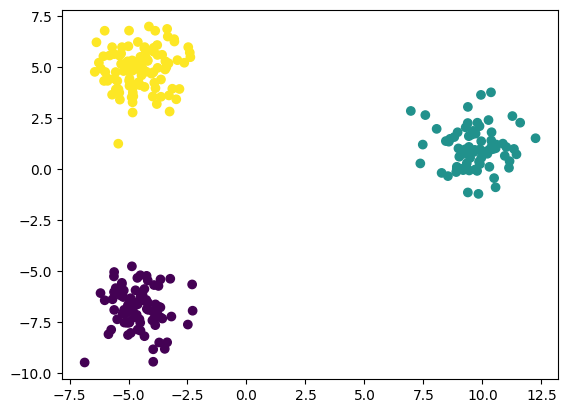

In [23]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

## For Validating the k value:
## Kneelocator
## Silhoutee scoring

In [24]:
## kneelocator

!pip install kneed


In [25]:
from kneed import KneeLocator
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')

In [26]:
kl.elbow

np.int64(3)

In [28]:
## Silhoutte score

from sklearn.metrics import silhouette_score
silhouette_coefficient=[]

for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficient.append(score)

In [29]:
silhouette_coefficient

[np.float64(0.5919058186520383),
 np.float64(0.8606366059988589),
 np.float64(0.6911685846978523),
 np.float64(0.5197699358015692),
 np.float64(0.36691875983193706),
 np.float64(0.3518359305445404),
 np.float64(0.3361746821741612),
 np.float64(0.3368031083490066),
 np.float64(0.3213785273151153)]

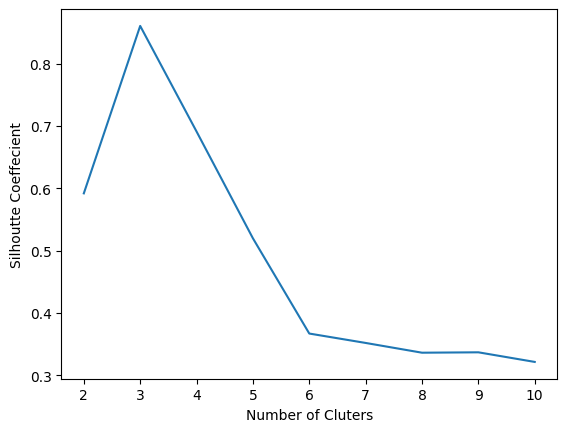

In [31]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficient)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()